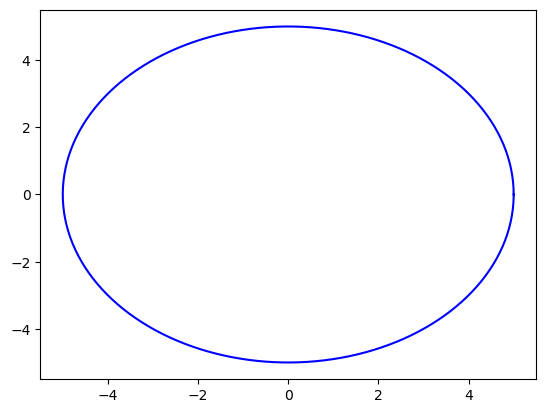

In [2]:
class Circle:
    def __init__(self, radius, color):
        self.radius = radius
        self.color = color 
    def Draw(self):
        theta_circle = np.linspace(0, 2*np.pi, 500)
        x = self.radius*np.cos(theta_circle)
        y = self.radius*np.sin(theta_circle)
        plt.plot(x, y, color=self.color, zorder=1)
circ=Circle(5, "blue")
circ.Draw()

In [ ]:
class Magnet:
    def __init__(self, mag_type, n_max, I0, ref_rad, r0, dr, n_radial, num_cond_quad):
        # Physical constant 
        self.mu0 = 4 * np.pi * 1e-7
        # User defined variables
        self.mag_type = mag_type
        self.n_max = n_max
        self.I0 = I0
        self.ref_rad = ref_rad
        self.r0 = r0
        self.dr = dr
        self.n_radial = n_radial 
        self.num_cond_quad = num_cond_quad
        # Derived variables
        self.inner_radius = r0 - dr/2
        self.outer_radius = (r0 + (n_radial[0] - 1) * dr) + dr/2
        self.num_conductors = 4*num_cond_quad

        # Need a block of funtions for total field calculation and plotting
        # Need a block of functions for field harmonic calculations in the refrerence radius

    # The field defined in terms of the harmonics
    def B_harm(self, x, y, x_a, y_a, I):
        # Position of the conductor
        a = np.hypot(x_a, y_a)
        
        # Position of field measurement
        r = np.hypot(x, y)
    
        # Angle between a and y=0
        phi = np.arctan2(y_a, x_a)
        # Angle between r and y=0
        theta = np.arctan2(y, x)
    
        # Angle between r and a
        ang = phi - theta
    
        # Replace r=0 with r=1e-20 to avoid divsion by zero
        r = np.where(r == 0, 1e-10, r)
    
        # Now we compute the field for both cases, adding up harmonics until the n_max harmonic is calculated and added
    
        # Case for r < a:
        B_r_in = ((self.mu0 * I) / (2 * np.pi * a)) * np.sum([(r / a)**(n - 1) * np.sin(n * ang) for n in range(1, self.n_max+1)], axis=0)
        B_theta_in = (-1)*((self.mu0 * I) / (2 * np.pi * a)) * np.sum([(r / a)**(n - 1) * np.cos(n * ang) for n in range(1, self.n_max+1)], axis=0)
        
        # Case for r > a:
        B_r_out = ((self.mu0 * I) / (2 * np.pi * a)) * np.sum([(a / r)**(n + 1) * np.sin(n * ang) for n in range(0, self.n_max+1)], axis=0)
        B_theta_out = ((self.mu0 * I) / (2 * np.pi * a)) * np.sum([(a / r)**(n + 1) * np.cos(n * ang) for n in range(0, self.n_max+1)], axis=0)
    
        # Use np.where to select the correct field values to return
        # np.where(cond., x, y) -> If true, takes x; if false, takes y
        B_r = np.where(r > a, B_r_out, B_r_in)
        B_theta = np.where(r > a, B_theta_out, B_theta_in)
    
        # Convert to cartesian coordinates (notably using the angle theta, not ang)
        B_x = B_r * np.cos(theta) - B_theta * np.sin(theta)
        B_y = B_r * np.sin(theta) + B_theta * np.cos(theta)
    
        return B_x, B_y


    # Contains the inverse cdfs for each of the first three pole magnets (dipole, quadrupole, sextupole)
    # Creates a list of theta values based on this to plot the conductors at
    def phi_list_maker(self, u, mag_type):  # Angle of the conductor so actually phi!!!
        
        if mag_type == 1:  # Dipole: cos(theta)
            phi_right = np.arcsin(u)
    
        elif mag_type == 2:  # Quadrupole: |cos(2theta)|
            phi_right = np.empty_like(u)
    
            # Split into lower and upper halves of the CDF
            lower_half = (u <= 0.5)
            upper_half = ~lower_half
    
            # Map u -> phi for each region
            # Invert CDF piecewise due to sharp points
            phi_right[lower_half] = 0.5 * np.arcsin(2 * u[lower_half])
            phi_right[upper_half] = 0.5 * np.pi - 0.5 * np.arcsin(2 * (1 - u[upper_half]))
    
        elif mag_type == 3:  # Sextupole: |cos(3theta)|
            phi_right = np.empty_like(u)
    
            # Each lobe = 1/3 probability
            s1 = (u <= 1.0/3.0)
            s2 = (u > 1.0/3.0) & (u <= 2.0/3.0)
            s3 = (u > 2.0/3.0)
    
            # Invert CDF piecewise due to sharp points
            phi_right[s1] = (1.0/3.0) * np.arcsin(3.0 * u[s1])
            phi_right[s2] = (np.pi/3.0) + (1.0/3.0)*np.arcsin(3.0*(u[s2] - 1.0/3.0))
            phi_right[s3] = (2.0*np.pi/3.0) + (1.0/3.0)*np.arcsin(3.0*(u[s3] - 2.0/3.0))
    
        else:
            raise ValueError("mag_type must be 1 (dipole), 2 (quadrupole), or 3 (sextupole).")
    
        # Mirror to other quadrants
        phi_left      = np.pi - phi_right
        phi_bot_left  = -phi_left
        phi_bot_right = -phi_right
    
        phi_list = np.sort(np.concatenate([phi_right, phi_left, phi_bot_left, phi_bot_right]))
        return phi_list


    # Maps out the wires and how they should be distributed
    # Current stays constant in magntitude for each conductor
    # Takes in the phi list from the distribution, and the radii list
    def wire_params(self, phi_list, radii_list):
        wire_params = []
        for phi in phi_list:
            for r in radii_list:
                # Wire locations
                x = r * np.cos(phi)
                y = r * np.sin(phi)
                
                if self.mag_type == 1:  # Dipole 
                    current = -self.I0 if x > 0 else (self.I0 if x < 0 else 0)
    
                elif self.mag_type == 2:  # Quadrupole (+ on ±x, − on ±y)
                    c = np.cos(2 * phi)
                    current = self.I0 if c > 0 else (-self.I0 if c < 0 else 0)
    
                elif self.mag_type == 3:  # Sextupole: alternate every 60° via cos(3theta)
                    c = np.cos(3 * phi)
                    current = self.I0 if c > 0 else (-self.I0 if c < 0 else 0)
    
                else:
                    raise ValueError("mag_type must be 1 (dipole), 2 (quadrupole), or 3 (sextupole).")
                
                wire_params.append((x, y, current))
        return wire_params


    # To calculate the individual harmonic at ref_rad (R0) due to a conductor with current I at position (a, phi)
    # Poles go by (n+1), so n=2 -> 3phi -> Sextupole
    # 0 = Dipole, 1=Quadrupole, 2=Sextupole, etc.
    # For a dipole, even harmonics are not allowed, so here we just look at odd constributions
    def Harmonic(self, R0, a, phi, n, I_wire):
        return (self.mu0*I_wire/2*np.pi) * (10**4) * ((R0 / a)**n) * np.cos((n + 1) * phi)
    
    
    # Calculate the harmonics from the given conductor parameter list at the reference radius R0 (ref_rad), going through the n-values given in n_list
    # Thus, calculates the harmonics for each conductor in the given wire layout and finds the total harmonics for each n in the reference radius
    def Total_Harms_from_wires(self, wire_param_list, n_list, R0):
        totals = np.zeros(len(n_list)) # Need to intialize to add to the initial zero, otherwise throws an error
        for (xw, yw, Iw) in wire_param_list:
            a   = np.hypot(xw, yw)
            phi = np.arctan2(yw, xw)
            for j, n_val in enumerate(n_list):
                totals[j] += self.Harmonic(R0, a, phi, n_val, Iw)  # Sign of current matters
        return totals


[[2.0, 2.3, 2.6, 2.9, 3.2]]
[[2.0, 2.3, 2.6, 2.9, 3.2], [3.5, 3.8]]
Harmonics [n=0,dipole, n=1,quad, n=2,sext, n=3,oct, n=4,deca]: [-2351.204628 -0.000000 9255.199696 0.000000 -188.853664]
Relative to main: [-0.254041 -0.000000 1.000000 0.000000 -0.020405]
Harmonics in 10^4 units: [-2540.414799 -0.000000 10000.000000 0.000000 -204.051420]


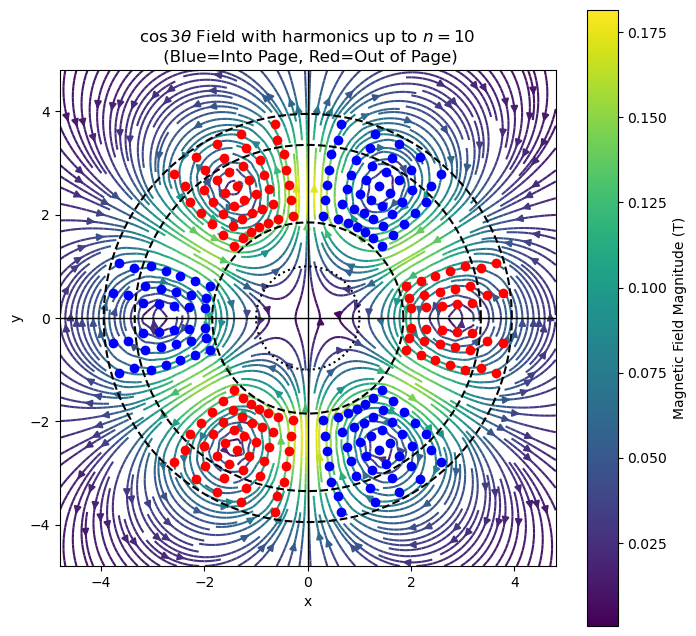

CPU times: total: 36.1 s
Wall time: 36.3 s


In [1]:
%%time
######################################## IMPORTS ##############################################
import numpy as np
from iminuit import Minuit
from iminuit.cost import UnbinnedNLL
from scipy.stats import norm
import panel as pn
import matplotlib.colors as mcolors
import matplotlib.pyplot as plt

######################################## SET CONSTANTS ##############################################

# Sets np values to not auto print in scientific notation for small numbers, but round to 6 decimal places
np.set_printoptions(suppress=True, formatter={'float_kind':'{:0.6f}'.format})

# The type of magnet being made: 1=Dipole, 2=Quardupole, 3=Sextupole, etc.
mag_type = 3

# Max harmonic we want the calculation to go up to:
# 1 = dipole, 2 = quadrupole, 3 = sextupole, etc.
n_max = 10

# Current magnitude
I0 = 16000

# Permeability
mu0 = 4 * np.pi * 1e-7 # Vacuum permeability

# Reference Radius (Good Field Region)
# This is the region in which the harmonics are calculated
ref_rad = 1

# Aperture radius: This is the radius of the opening
r0 = 2

# Radial spacing between conductors
dr = 0.3 

# Number of "wires" in each layer section
n_radial = [5, 2]

# A list of the numbers of conductors ("cables") in each layer:
num_cond_quad = [10, 7] 

######################################## DERIVED CONSTANTS ##############################################

# Inner wall radius
inner_radius = r0 - dr/2

# First layer outer radius:
outer_radius = (r0 + (n_radial[0] - 1) * dr) + dr/2

# Number of conductors per layer:
num_conductors = 4*num_cond_quad

######################################## FUNCTIONS ##############################################


# The field defined in terms of the harmonics
def B_harm(x, y, x_a, y_a, I):
    # Position of the conductor
    a = np.hypot(x_a, y_a)
    
    # Position of field measurement
    r = np.hypot(x, y)

    # Angle between a and y=0
    phi = np.arctan2(y_a, x_a)
    # Angle between r and y=0
    theta = np.arctan2(y, x)

    # Angle between r and a
    ang = phi - theta

    # Replace r=0 with r=1e-20 to avoid divsion by zero
    r = np.where(r == 0, 1e-10, r)

    # Now we compute the field for both cases, adding up harmonics until the n_max harmonic is calculated and added

    # Case for r < a:
    B_r_in = ((mu0 * I) / (2 * np.pi * a)) * np.sum([(r / a)**(n - 1) * np.sin(n * ang) for n in range(1, n_max+1)], axis=0)
    B_theta_in = (-1)*((mu0 * I) / (2 * np.pi * a)) * np.sum([(r / a)**(n - 1) * np.cos(n * ang) for n in range(1, n_max+1)], axis=0)
    
    # Case for r > a:
    B_r_out = ((mu0 * I) / (2 * np.pi * a)) * np.sum([(a / r)**(n + 1) * np.sin(n * ang) for n in range(0, n_max+1)], axis=0)
    B_theta_out = ((mu0 * I) / (2 * np.pi * a)) * np.sum([(a / r)**(n + 1) * np.cos(n * ang) for n in range(0, n_max+1)], axis=0)

    # Use np.where to select the correct field values to return
    # np.where(cond., x, y) -> If true, takes x; if false, takes y
    B_r = np.where(r > a, B_r_out, B_r_in)
    B_theta = np.where(r > a, B_theta_out, B_theta_in)

    # Convert to cartesian coordinates (notably using the angle theta, not ang)
    B_x = B_r * np.cos(theta) - B_theta * np.sin(theta)
    B_y = B_r * np.sin(theta) + B_theta * np.cos(theta)

    return B_x, B_y


# Contains the inverse cdfs for each of the first three pole magnets (dipole, quadrupole, sextupole)
# Creates a list of theta values based on this to plot the conductors at
def phi_list_maker(u, mag_type):  # Angle of the conductor so actually phi!!!
    
    if mag_type == 1:  # Dipole: cos(theta)
        phi_right = np.arcsin(u)

    elif mag_type == 2:  # Quadrupole: |cos(2theta)|
        phi_right = np.empty_like(u)

        # Split into lower and upper halves of the CDF
        lower_half = (u <= 0.5)
        upper_half = ~lower_half

        # Map u -> phi for each region
        # Invert CDF piecewise due to sharp points
        phi_right[lower_half] = 0.5 * np.arcsin(2 * u[lower_half])
        phi_right[upper_half] = 0.5 * np.pi - 0.5 * np.arcsin(2 * (1 - u[upper_half]))

    elif mag_type == 3:  # Sextupole: |cos(3theta)|
        phi_right = np.empty_like(u)

        # Each lobe = 1/3 probability
        s1 = (u <= 1.0/3.0)
        s2 = (u > 1.0/3.0) & (u <= 2.0/3.0)
        s3 = (u > 2.0/3.0)

        # Invert CDF piecewise due to sharp points
        phi_right[s1] = (1.0/3.0) * np.arcsin(3.0 * u[s1])
        phi_right[s2] = (np.pi/3.0) + (1.0/3.0)*np.arcsin(3.0*(u[s2] - 1.0/3.0))
        phi_right[s3] = (2.0*np.pi/3.0) + (1.0/3.0)*np.arcsin(3.0*(u[s3] - 2.0/3.0))

    else:
        raise ValueError("mag_type must be 1 (dipole), 2 (quadrupole), or 3 (sextupole).")

    # Mirror to other quadrants
    phi_left      = np.pi - phi_right
    phi_bot_left  = -phi_left
    phi_bot_right = -phi_right

    phi_list = np.sort(np.concatenate([phi_right, phi_left, phi_bot_left, phi_bot_right]))
    return phi_list


# Maps out the wires and how they should be distributed
# Current stays constant in magntitude for each conductor
# Takes in the phi list from the distribution, and the radii list
def wire_params(phi_list, radii_list):
    wire_params = []
    for phi in phi_list:
        for r in radii_list:
            # Wire locations
            x = r * np.cos(phi)
            y = r * np.sin(phi)
            
            if mag_type == 1:  # Dipole 
                current = -I0 if x > 0 else (I0 if x < 0 else 0)

            elif mag_type == 2:  # Quadrupole (+ on ±x, − on ±y)
                c = np.cos(2 * phi)
                current = I0 if c > 0 else (-I0 if c < 0 else 0)

            elif mag_type == 3:  # Sextupole: alternate every 60° via cos(3theta)
                c = np.cos(3 * phi)
                current = I0 if c > 0 else (-I0 if c < 0 else 0)

            else:
                raise ValueError("mag_type must be 1 (dipole), 2 (quadrupole), or 3 (sextupole).")
            
            wire_params.append((x, y, current))
    return wire_params


# To calculate the individual harmonic at ref_rad (R0) due to a conductor with current I at position (a, phi)
# Poles go by (n+1), so n=2 -> 3phi -> Sextupole
# 0 = Dipole, 1=Quadrupole, 2=Sextupole, etc.
# For a dipole, even harmonics are not allowed, so here we just look at odd constributions
def Harmonic(R0, a, phi, n, I_wire):
    return (mu0*I_wire/2*np.pi) * (10**4) * ((R0 / a)**n) * np.cos((n + 1) * phi)


# Calculate the harmonics from the given conductor parameter list at the reference radius R0 (ref_rad), going through the n-values given in n_list
# Thus, calculates the harmonics for each conductor in the given wire layout and finds the total harmonics for each n in the reference radius
def Total_Harms_from_wires(wire_param_list, n_list, R0):
    totals = np.zeros(len(n_list)) # Need to intialize to add to the initial zero, otherwise throws an error
    for (xw, yw, Iw) in wire_param_list:
        a   = np.hypot(xw, yw)
        phi = np.arctan2(yw, xw)
        for j, n_val in enumerate(n_list):
            totals[j] += Harmonic(R0, a, phi, n_val, Iw)  # Sign of current matters
    return totals

######################################## CALCULATIONS ##############################################

# TO-DO: Encapsulate the strict cos theta dists for testing, then add the ability to:
# - Add a certain amount of blocks with a certain amount of cables in each
# - Be able to determine the angle of each block of cables

# Uniformly spaced cumulative values (excluding 0 and 1 to avoid endpoints)
# Done for the number of conductors in each layer
# Each entry is for a single layer
parent_u_list = []
for i in range(len(num_cond_quad)): # For each layer
    parent_u_list.append(np.linspace(0, 1, num_cond_quad[i] + 2)[1:-1])

# Creates a master list of the theta distributions for each layer:
# This is based on the u defined for each layer in the previous calculation
# Each entry is for a single layer
parent_phi_list = []
for i in range(len(parent_u_list)): # For each layer
    parent_phi_list.append(phi_list_maker(parent_u_list[i], mag_type))

# Determines the radial position of wires in each layer
# Recall: n_radial = [5, 6, 2] -> Number of "wires" in each layer section (cable)
layer_radii = []
for j in range(len(n_radial)): # For each layer
    if j == 0: # First layer radii values
        layer_radii.append( [r0 + i * dr for i in range(n_radial[0])] )
    else: # All other layer radii values, adds to the top of the last layer
        layer_radii.append( [(layer_radii[j-1][-1] + dr + i * dr) for i in range(n_radial[j])] ) 
    print(layer_radii)

# Wire params parent list for each layer
# This creates a list of the layour for each layer
total_wire_params = []
for i in range(len(layer_radii)):
    total_wire_params.append(wire_params(parent_phi_list[i], layer_radii[i]))

# Auto-sets the bounds based on the outer layer's radius to see all layers:
# bounds = [ x min & max, y min & max ]
# Used for both field calculation and plotting to minimize computation
bounds = [ [(-1)*(layer_radii[i][-1]+1), layer_radii[i][-1]+1], [(-1)*(layer_radii[i][-1]+1), layer_radii[i][-1]+1] ]
# Bounds for first quadrant only:
#bounds =  [ [0, layer_radii[i][-1]+1], [0, layer_radii[i][-1]+1] ]


# Grid setup (for plotting the field)
# The field is always calculated everywhere in this region
x = np.linspace(bounds[0][0], bounds[0][1], 250)
y = np.linspace(bounds[1][0], bounds[1][1], 250)
X, Y = np.meshgrid(x, y)

Bx_total = np.zeros_like(X)
By_total = np.zeros_like(Y)

# Calculate field for each wire component
# Here, we iterate over each layer and each wire in each layer, and add its field contribution
# From this, we get a map of the total field everywhere
for params in total_wire_params:
    for xa, ya, I in params:
        Bx, By = B_harm(X, Y, xa, ya, I)
        Bx_total += Bx
        By_total += By

# Total B-field magnitudes are computed
B_mag = np.hypot(Bx_total, By_total)


# Here we caluclate the harmonic components for each n in n_list witin the given ref_rad
n_list = [0, 1, 2, 3, 4]  # dipole, quadrupole, sextupole, octupole, deacpole

B_main_index = mag_type - 1 # From the magtype definition, sets main field to whatever the magnet type is set to


# Calculates the total harmonics taking into account each layer
# Give us a list of the total wire parameters in every layer
all_wires = []
for layer in total_wire_params:
    for wire in layer:
        all_wires.append(wire)

harms = Total_Harms_from_wires(all_wires, n_list, ref_rad)

print("Harmonics [n=0,dipole, n=1,quad, n=2,sext, n=3,oct, n=4,deca]:", harms)
print("Relative to main:", harms / (harms[B_main_index] if harms[B_main_index] != 0 else 1))

# convert to 10^4 units relative to main multipole:
B_main = harms[B_main_index]  # for dipole magnet, n=0 is main
units = (harms / B_main) * 1e4
print("Harmonics in 10^4 units:", units)

######################################## PLOTTING ##############################################
plt.figure(figsize=(8, 8))

# Stream plot of magnetic field
#norm = mcolors.Normalize(vmin=B_mag.min(), vmax=np.percentile(B_mag, 95)) 
strm = plt.streamplot(X, Y, Bx_total, By_total, color=B_mag, cmap='viridis', density=3, zorder=0)
cbar = plt.colorbar(strm.lines, label='Magnetic Field Magnitude (T)')

# Plot each of the wires in each layer
for params in total_wire_params:
    for xa, ya, I in params:
        color = 'r' if I > 0 else 'b'
        plt.plot(xa, ya, 'o', color=color, zorder=2)

# Defines the angular space to plot the cirles in the plot
theta_circle = np.linspace(0, 2*np.pi, 500)

# Plot of the reference radius
x_ref = ref_rad * np.cos(theta_circle)
y_ref = ref_rad * np.sin(theta_circle)
plt.plot(x_ref, y_ref, 'k:', zorder=1)

# Plot of the inner wall radius
x_circle = inner_radius * np.cos(theta_circle)
y_circle = inner_radius * np.sin(theta_circle)
plt.plot(x_circle, y_circle, 'k--', zorder=1)

# Plot of the first layer outer radius
x_outer = outer_radius * np.cos(theta_circle)
y_outer = outer_radius * np.sin(theta_circle)
plt.plot(x_outer, y_outer, 'k--', zorder=1)

# Plots each subsequent layer's radius
# Radius = last point + dr
for i in range(len(layer_radii)):
    if i == 0: # Skip the first layer since that plots earlier
        pass
    else: # Prints other layer radii
        x_layer = (layer_radii[i][-1]+dr/2) * np.cos(theta_circle) # The [-1] index accesses the last value in the list
        y_layer = (layer_radii[i][-1]+dr/2) * np.sin(theta_circle)
        plt.plot(x_layer, y_layer, 'k--', zorder=1)

# Axes & final layout
plt.axhline(0, color='black', linewidth=1, zorder=1)
plt.axvline(0, color='black', linewidth=1, zorder=1)
plt.gca().set_aspect('equal')
plt.xlim(bounds[0][0], bounds[0][1])
plt.ylim(bounds[1][0], bounds[1][1])
plt.xlabel("x")
plt.ylabel("y")
plt.title(f"$\\cos {mag_type}\\theta$ Field with harmonics up to $n=${n_max} \n (Blue=Into Page, Red=Out of Page)")
plt.show()